In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data hasil eksperimen dari notebook 03 dan 04
data = {
    'Model': ['Naive Bayes', 'Logistic Regression', 'Random Forest', 'SVM (LinearSVC)', 'PyTorch NN (MiniLM)', 'XGBoost'],
    'Feature_Type': ['TF-IDF', 'TF-IDF', 'TF-IDF', 'TF-IDF', 'Semantic Embeddings', 'TF-IDF'],
    'Accuracy (%)': [54.53, 65.59, 68.81, 71.43, 74.65, 77.87],
    'Training_Time (Detik)': [0.01, 1.18, 5.96, 0.71, 8.20, 134.02]
}

df_compare = pd.DataFrame(data)
df_compare = df_compare.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)
display(df_compare)

,Model,Feature_Type,Accuracy (%),Training_Time (Detik)
0,XGBoost,TF-IDF,77.87,134.02
1,PyTorch NN (MiniLM),Semantic Embeddings,74.65,8.20
2,SVM (LinearSVC),TF-IDF,71.43,0.71
3,Random Forest,TF-IDF,68.81,5.96
4,Logistic Regression,TF-IDF,65.59,1.18
5,Naive Bayes,TF-IDF,54.53,0.01


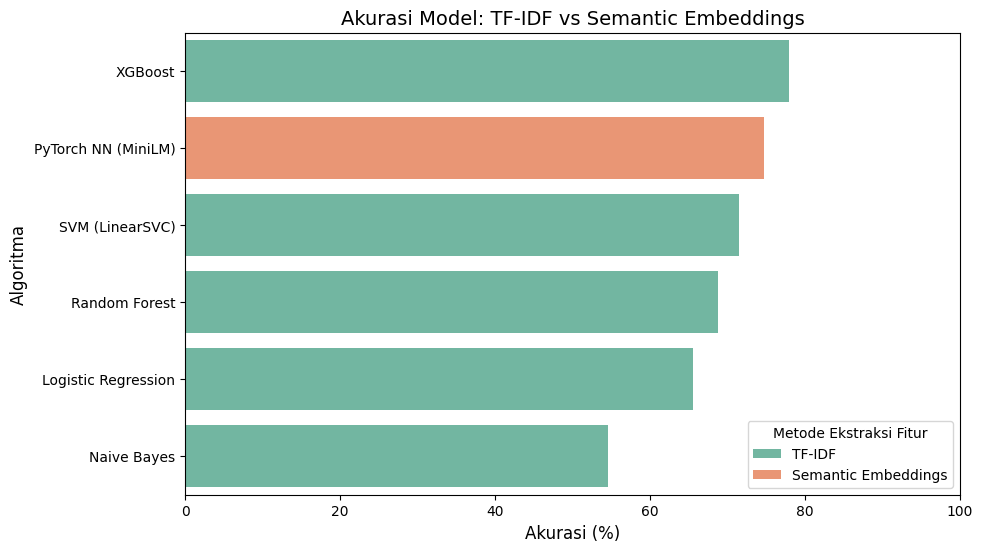

In [2]:
# Visualisasi 1: Perbandingan Akurasi
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy (%)", y="Model", hue="Feature_Type", dodge=False, data=df_compare, palette="Set2")
plt.title("Akurasi Model: TF-IDF vs Semantic Embeddings", fontsize=14)
plt.xlabel("Akurasi (%)", fontsize=12)
plt.ylabel("Algoritma", fontsize=12)
plt.xlim(0, 100)
plt.legend(title="Metode Ekstraksi Fitur", loc='lower right')
plt.show()

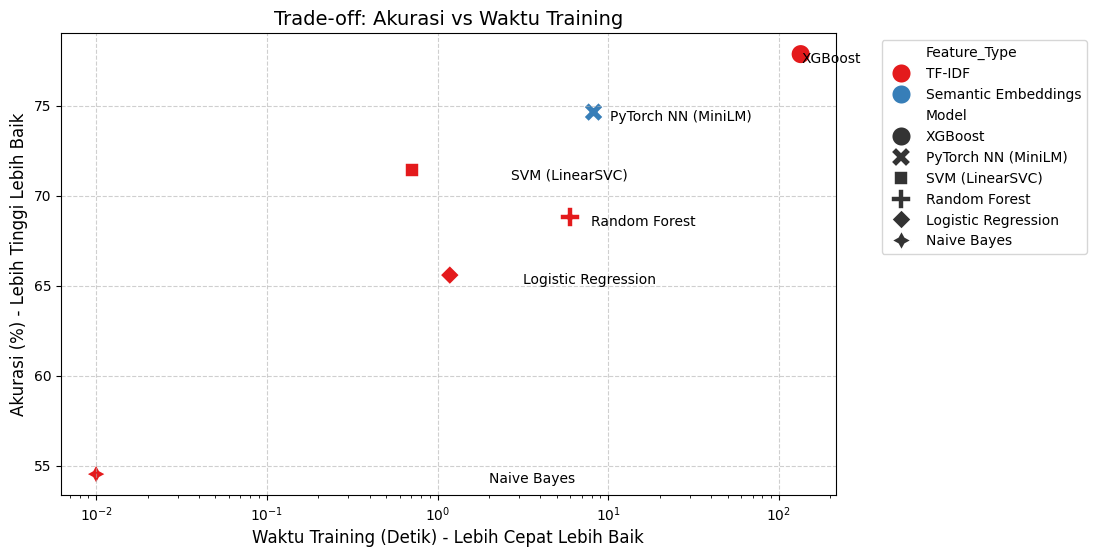

In [3]:
# Visualisasi 2: Trade-off antara Akurasi vs Waktu Komputasi
# Sangat penting di dunia industri nyata (Production)

plt.figure(figsize=(10, 6))
sns.scatterplot(x="Training_Time (Detik)", y="Accuracy (%)", hue="Feature_Type", style="Model", s=200, data=df_compare, palette="Set1")

# Menambahkan label untuk setiap titik
for i, row in df_compare.iterrows():
    plt.annotate(row['Model'], (row['Training_Time (Detik)'] + 2, row['Accuracy (%)'] - 0.5), fontsize=10)

plt.title("Trade-off: Akurasi vs Waktu Training", fontsize=14)
plt.xlabel("Waktu Training (Detik) - Lebih Cepat Lebih Baik", fontsize=12)
plt.ylabel("Akurasi (%) - Lebih Tinggi Lebih Baik", fontsize=12)
plt.xscale('log') # Skala logaritma karena perbedaan waktu sangat jauh
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()